# Import libraries and data

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.under_sampling import RandomUnderSampler

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Load the data
dfcus = pd.read_csv('C:/Users/Katlego/OneDrive/Desktop/Data/CSIS3754/bank_customers.csv')

print("Data loaded successfully.")
print(f"Dataset shape: {dfcus.shape}")

Data loaded successfully.
Dataset shape: (10127, 23)


#  Inspect the data 

In [2]:
# 2.2.1 Concise summary of the dataframe
print("\n--- DATAFRAME INFO (Concise Summary) ---")
print(dfcus.info())

# 2.2.2 Number of unique values for each feature
print("\n--- UNIQUE VALUES PER FEATURE ---")
unique_counts = dfcus.nunique()
print(unique_counts)

# Display as DataFrame for better readability
unique_df = pd.DataFrame({
    'Feature': unique_counts.index,
    'Unique Values': unique_counts.values
})
print("\nUnique values summary table:")
print(unique_df.to_string(index=False))


--- DATAFRAME INFO (Concise Summary) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit       

# Discard first column and last 7 column

In [3]:
# Get original column names for reference
original_cols = dfcus.columns.tolist()
print(f"Original columns ({len(original_cols)} total):")
print(original_cols)

# Discard first column and last 7 columns
# iloc[:, 1:-7] means: all rows, start from column index 1, stop before last 7 columns
dfcus = dfcus.iloc[:, 1:-7]

print(f"\nRemoved first column: '{original_cols[0]}'")
print(f"Removed last 7 columns: {original_cols[-7:]}")

print(f"\nNew shape: {dfcus.shape}")
print(f"Remaining columns ({len(dfcus.columns)} total):")
print(dfcus.columns.tolist())

Original columns (23 total):
['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_Classifier_1', 'Naive_Bayes_Classifier_2']

Removed first column: 'CLIENTNUM'
Removed last 7 columns: ['Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_Classifier_1', 'Naive_Bayes_Classifier_2']

New shape: (10127, 15)
Remaining columns (15 total):
['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Cou

# Generate a statistical summary of all the features

In [4]:
print(dfcus.describe())

       Customer_Age  Dependent_count  Months_on_book  \
count  10127.000000     10127.000000    10127.000000   
mean      46.325960         2.346203       35.928409   
std        8.016814         1.298908        7.986416   
min       26.000000         0.000000       13.000000   
25%       41.000000         1.000000       31.000000   
50%       46.000000         2.000000       36.000000   
75%       52.000000         3.000000       40.000000   
max       73.000000         5.000000       56.000000   

       Total_Relationship_Count  Months_Inactive_12_mon  \
count              10127.000000            10127.000000   
mean                   3.812580                2.341167   
std                    1.554408                1.010622   
min                    1.000000                0.000000   
25%                    3.000000                2.000000   
50%                    4.000000                2.000000   
75%                    5.000000                3.000000   
max                    

#  Deduction about marital status

In [5]:
print("""
From the statistical summary (describe()), the Marital_Status column is 
categorical and does not appear in the numeric summary. However, from the 
unique value inspection (nunique) and value_counts, we can see there are 
4 distinct marital status values: Married, Single, Divorced, and Unknown.

The most frequent marital status is 'Married' (4687 customers), followed 
by 'Single' (3943), while 'Unknown' (749) and 'Divorced' (748) appear 
far less frequently. This means the majority of credit card customers 
in this dataset are married or single, and a small proportion did not 
disclose their marital status.
""")


From the statistical summary (describe()), the Marital_Status column is 
categorical and does not appear in the numeric summary. However, from the 
unique value inspection (nunique) and value_counts, we can see there are 
4 distinct marital status values: Married, Single, Divorced, and Unknown.

The most frequent marital status is 'Married' (4687 customers), followed 
by 'Single' (3943), while 'Unknown' (749) and 'Divorced' (748) appear 
far less frequently. This means the majority of credit card customers 
in this dataset are married or single, and a small proportion did not 
disclose their marital status.



#  Visualisations using Seaborn

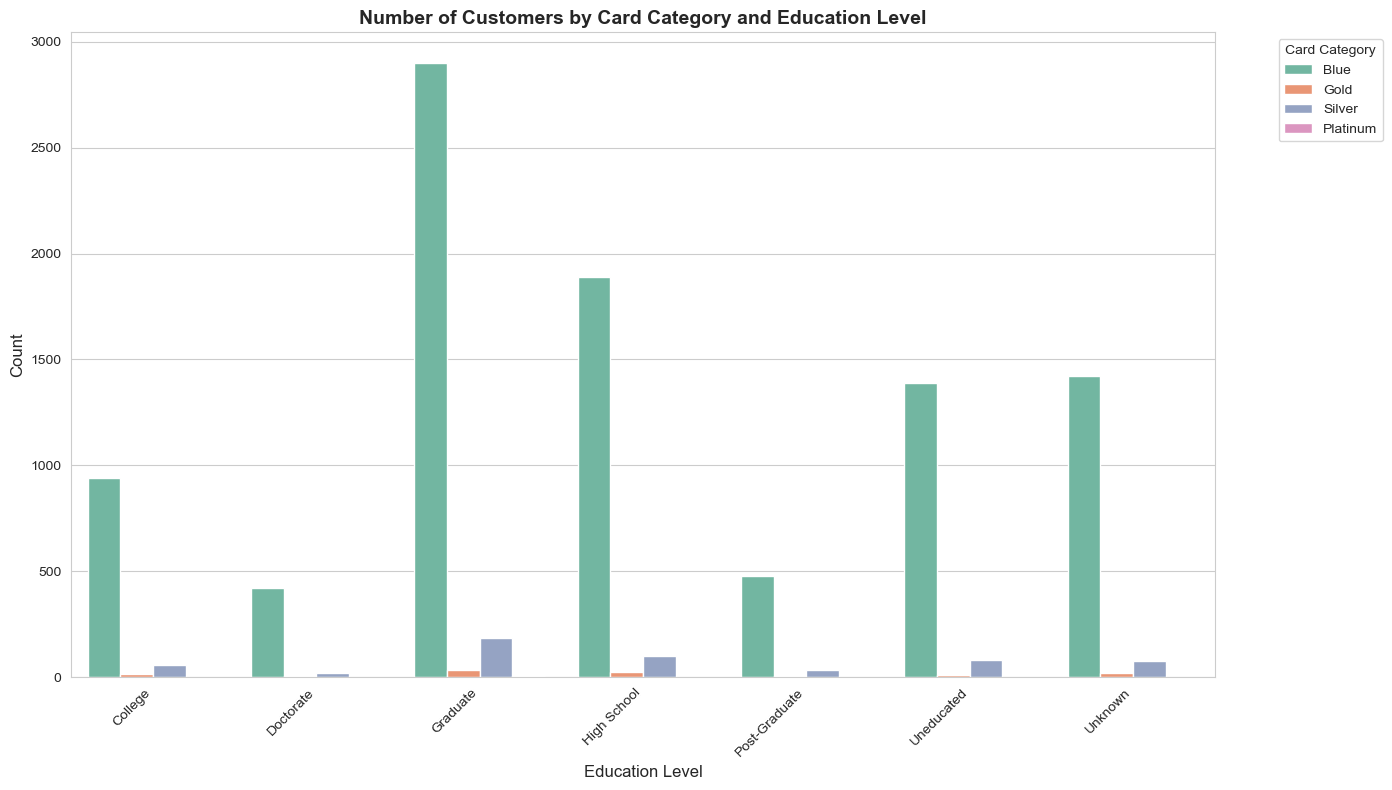


Discussion: The 'Blue' card category dominates across all education levels, 
indicating it is the most common card type regardless of education. 
Graduate and High School educated customers make up the largest groups. 
Platinum card holders are very rare across all education levels, suggesting 
it is a premium tier with limited uptake.



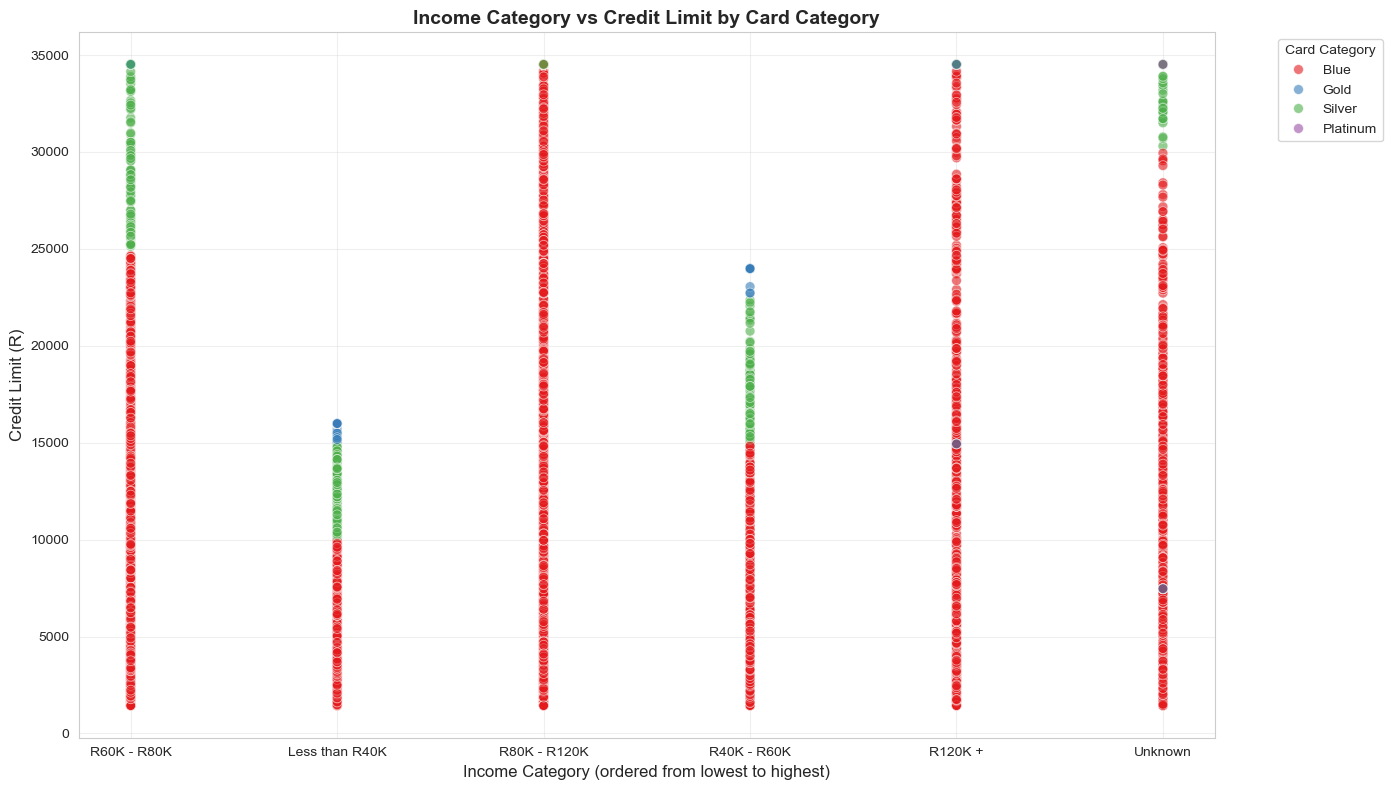


Discussion: Customers in higher income brackets (R120K+) tend to have higher 
credit limits. Platinum and Gold card holders cluster toward the higher credit 
limit ranges. Blue card holders are spread across all income and credit limit 
levels, confirming it is the most broadly accessible card category.



In [6]:
# Set the style for better-looking plots
sns.set_style("whitegrid")

# 2.5.1 Categorical plot: Card Category for each Education Level
plt.figure(figsize=(14, 8))

# Create countplot
ax = sns.countplot(data=dfcus, 
                   x='Education_Level', 
                   hue='Card_Category',
                   order=sorted(dfcus['Education_Level'].dropna().unique()),
                   palette='Set2')

plt.title('Number of Customers by Card Category and Education Level', 
          fontsize=14, fontweight='bold')
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Card Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Discussion for plot 1
print("""
Discussion: The 'Blue' card category dominates across all education levels, 
indicating it is the most common card type regardless of education. 
Graduate and High School educated customers make up the largest groups. 
Platinum card holders are very rare across all education levels, suggesting 
it is a premium tier with limited uptake.
""")


plt.figure(figsize=(14, 8))

# Convert Income Category to numeric order for better plotting
income_order = ['Less than $40K', '$40K - $60K', '$60K - $80K', 
                '$80K - $120K', '$120K +', 'Unknown']
if all(cat in income_order for cat in dfcus['Income_Category'].unique()):
    # Create a numeric mapping for x-axis ordering
    income_map = {cat: i for i, cat in enumerate(income_order)}
    dfcus['Income_Category_Num'] = dfcus['Income_Category'].map(income_map)
    x_col = 'Income_Category_Num'
    x_labels = income_order
else:
    x_col = 'Income_Category'
    x_labels = sorted(dfcus['Income_Category'].unique())

# Create scatter plot
scatter = sns.scatterplot(data=dfcus, 
                          x=x_col, 
                          y='Credit_Limit', 
                          hue='Card_Category', 
                          alpha=0.6, 
                          s=50,
                          palette='Set1')

plt.title('Income Category vs Credit Limit by Card Category', 
          fontsize=14, fontweight='bold')
plt.xlabel('Income Category (ordered from lowest to highest)', fontsize=12)
plt.ylabel('Credit Limit (R)', fontsize=12)

# Set x-tick labels if using numeric mapping
if x_col == 'Income_Category_Num':
    plt.xticks(ticks=range(len(x_labels)), labels=x_labels, rotation=45, ha='right')

plt.legend(title='Card Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Discussion for plot 2
print("""
Discussion: Customers in higher income brackets (R120K+) tend to have higher 
credit limits. Platinum and Gold card holders cluster toward the higher credit 
limit ranges. Blue card holders are spread across all income and credit limit 
levels, confirming it is the most broadly accessible card category.
""")

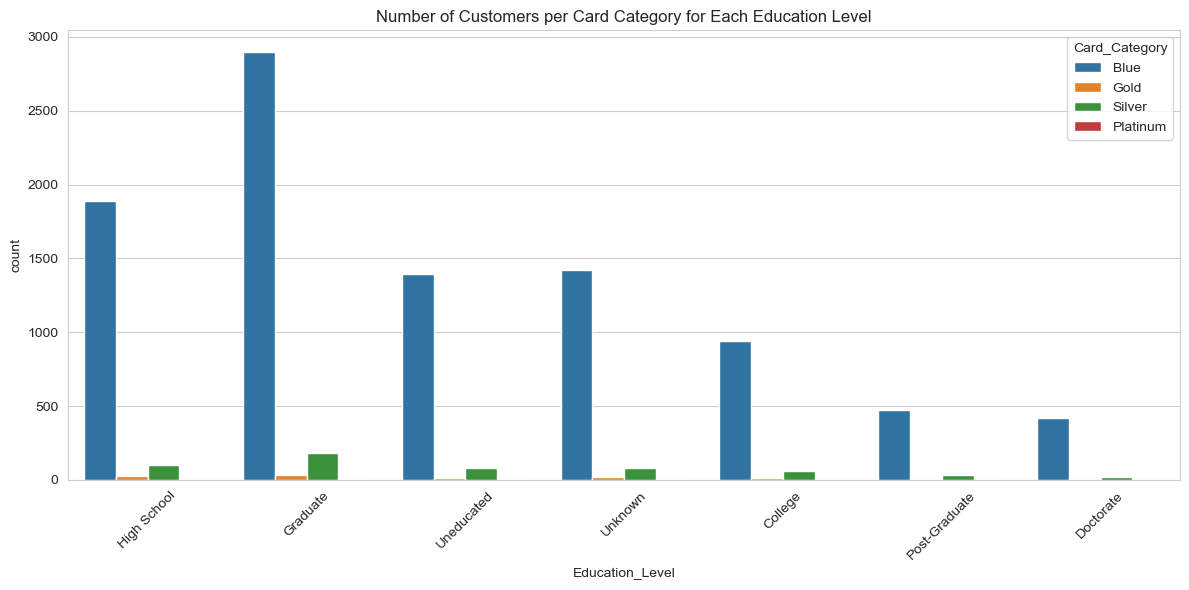


Discussion: The 'Blue' card category dominates across all education levels, 
indicating it is the most common card type regardless of education. 
Graduate and High School educated customers make up the largest groups. 
Platinum card holders are very rare across all education levels, suggesting 
it is a premium tier with limited uptake.



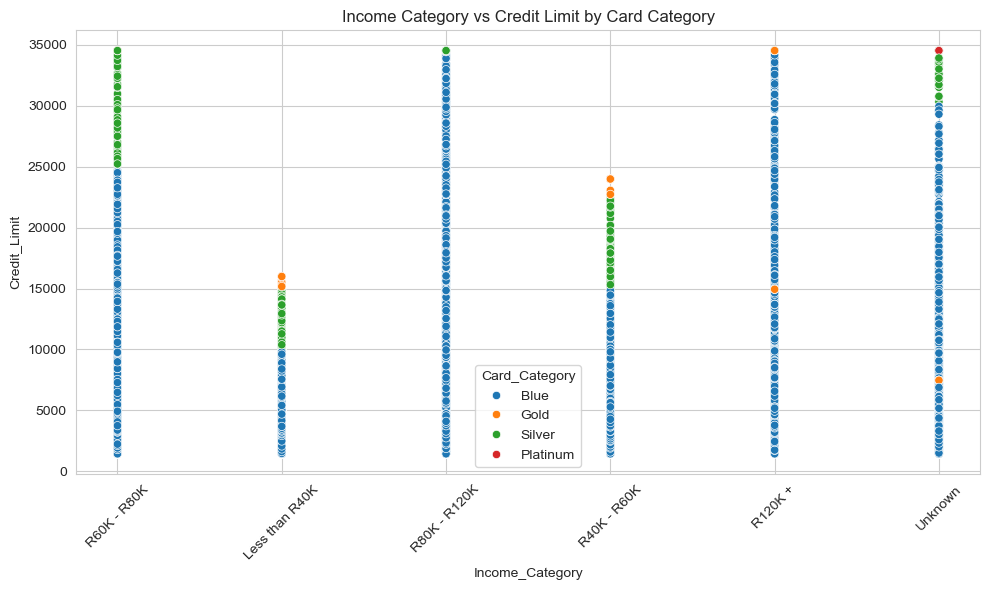


Discussion: Customers in higher income brackets (R120K+) tend to have higher 
credit limits. Platinum and Gold card holders cluster toward the higher credit 
limit ranges. Blue card holders are spread across all income and credit limit 
levels, confirming it is the most broadly accessible card category.



In [7]:
# Plot 1: Categorical plot — Customers per Card Category for each Education Level
plt.figure(figsize=(12, 6))
sns.countplot(data=dfcus, x='Education_Level', hue='Card_Category')
plt.title('Number of Customers per Card Category for Each Education Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("""
Discussion: The 'Blue' card category dominates across all education levels, 
indicating it is the most common card type regardless of education. 
Graduate and High School educated customers make up the largest groups. 
Platinum card holders are very rare across all education levels, suggesting 
it is a premium tier with limited uptake.
""")

# Plot 2: Combined scatter plot — Income Category vs Credit Limit per Card Category
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dfcus, x='Income_Category', y='Credit_Limit', hue='Card_Category')
plt.title('Income Category vs Credit Limit by Card Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("""
Discussion: Customers in higher income brackets (R120K+) tend to have higher 
credit limits. Platinum and Gold card holders cluster toward the higher credit 
limit ranges. Blue card holders are spread across all income and credit limit 
levels, confirming it is the most broadly accessible card category.
""")


# Check data balance with pie chart 

Customer distribution:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Existing Customer percentage: 83.9%
Attrited Customer percentage: 16.1%


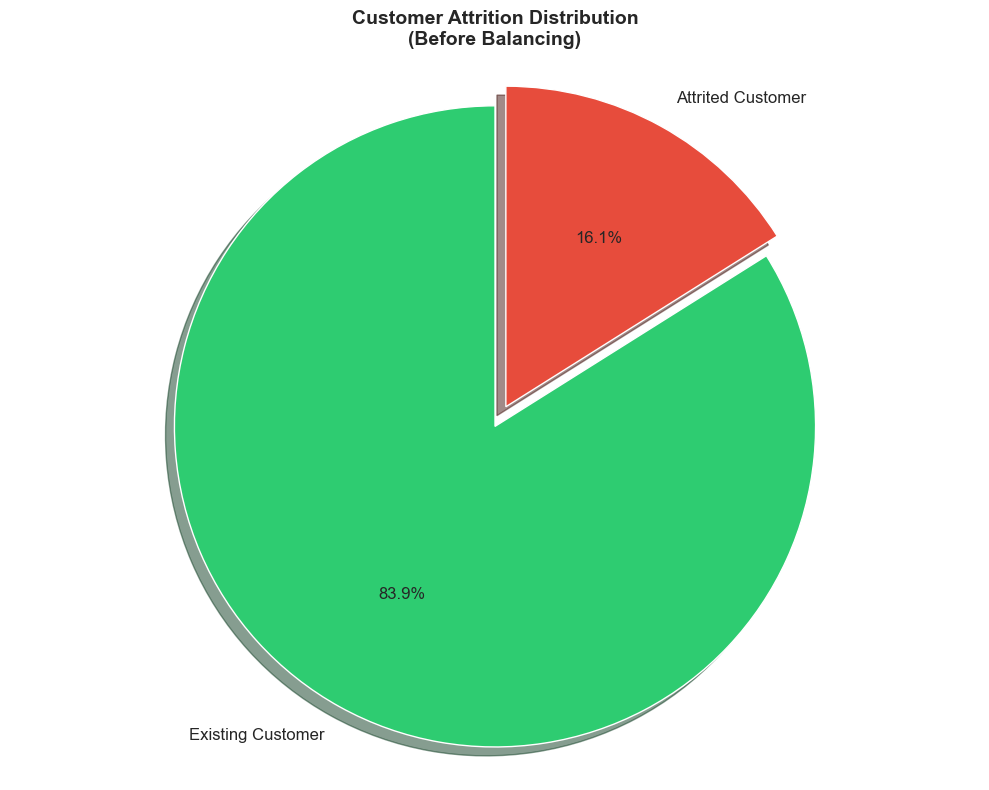


--- BALANCE ASSESSMENT ---
Imbalance Ratio (minority/majority): 0.191

⚠️ The dataset is IMBALANCED. Undersampling is recommended.
   The minority class (Attrited Customers) has only 19.1%
   of the majority class (Existing Customers).


In [8]:
# Check the distribution of Attrition_Flag
attrition_counts = dfcus['Attrition_Flag'].value_counts()
print("Customer distribution:")
print(attrition_counts)

# Calculate percentages
total = len(dfcus)
existing_pct = (attrition_counts.get('Existing Customer', 0) / total) * 100
attrited_pct = (attrition_counts.get('Attrited Customer', 0) / total) * 100

print(f"\nExisting Customer percentage: {existing_pct:.1f}%")
print(f"Attrited Customer percentage: {attrited_pct:.1f}%")

# 2.6.1 Create pie chart with percentages rounded to 1 decimal
plt.figure(figsize=(10, 8))
colors_pie = ['#2ecc71', '#e74c3c']
explode_pie = (0.02, 0.05)  # Slightly explode the smaller slice

def autopct_format(pct):
    """Format percentage to 1 decimal place."""
    return f'{pct:.1f}%'

plt.pie(attrition_counts.values, 
        labels=attrition_counts.index, 
        autopct=autopct_format,
        colors=colors_pie,
        explode=explode_pie,
        startangle=90,
        shadow=True,
        textprops={'fontsize': 12})
plt.title('Customer Attrition Distribution\n(Before Balancing)', 
          fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

# Determine if balanced
print("\n--- BALANCE ASSESSMENT ---")
ratio = min(attrition_counts) / max(attrition_counts)
print(f"Imbalance Ratio (minority/majority): {ratio:.3f}")

if ratio < 0.8:
    print("\n⚠️ The dataset is IMBALANCED. Undersampling is recommended.")
    print(f"   The minority class (Attrited Customers) has only {ratio*100:.1f}%")
    print("   of the majority class (Existing Customers).")
else:
    print("\n✓ The dataset is relatively balanced.")

#  Undersample to balance the data 

In [9]:
# Separate features and target
X = dfcus.drop('Attrition_Flag', axis=1)
y = dfcus['Attrition_Flag']

print("Before undersampling:")
print(f"  X shape: {X.shape}")
print(f"  y distribution:")
print(f"    {y.value_counts().to_string()}")

# Apply undersampling
undersampler = RandomUnderSampler(random_state=42, sampling_strategy='auto')
X_resampled, y_resampled = undersampler.fit_resample(X, y)

# Create the resampled dataframe
dfcus_resampled = pd.DataFrame(X_resampled, columns=X.columns)
dfcus_resampled['Attrition_Flag'] = y_resampled

print(f"\nAfter undersampling:")
print(f"  X_resampled shape: {X_resampled.shape}")
print(f"  y_resampled distribution:")
print(f"    {y_resampled.value_counts().to_string()}")

# Count the number of records in each class
print("\n" + "="*60)
print("RESAMPLING CONFIRMATION")
print("="*60)
resampled_counts = dfcus_resampled['Attrition_Flag'].value_counts()
print("Records per customer group after undersampling:")
print(resampled_counts)
print(f"\nTotal records after resampling: {len(dfcus_resampled)}")

print(f"\n✓ Undersampling completed successfully.")
print(f"  Both classes now have equal representation.")

Before undersampling:
  X shape: (10127, 14)
  y distribution:
    Attrition_Flag
Existing Customer    8500
Attrited Customer    1627

After undersampling:
  X_resampled shape: (3254, 14)
  y_resampled distribution:
    Attrition_Flag
Attrited Customer    1627
Existing Customer    1627

RESAMPLING CONFIRMATION
Records per customer group after undersampling:
Attrition_Flag
Attrited Customer    1627
Existing Customer    1627
Name: count, dtype: int64

Total records after resampling: 3254

✓ Undersampling completed successfully.
  Both classes now have equal representation.


# Convert text to numeric values 

In [10]:
# Make a copy to work with
dfcus_encoded = dfcus_resampled.copy()

# Identify columns with text values (object type)
object_columns = dfcus_encoded.select_dtypes(include=['object']).columns.tolist()
print(f"Columns with text values: {object_columns}")

# Separate target from features (we'll encode target separately)
if 'Attrition_Flag' in object_columns:
    object_columns.remove('Attrition_Flag')

# 2.8.1 Convert binary columns (2 unique values) to [0, 1]
binary_cols = []
multi_cols = []

for col in object_columns:
    unique_count = dfcus_encoded[col].nunique()
    if unique_count == 2:
        binary_cols.append(col)
    else:
        multi_cols.append(col)

print(f"\nBinary columns (2 unique values): {binary_cols}")
print(f"Multi-class columns (>2 unique values): {multi_cols}")

# Convert binary columns
print("\n--- Binary Encoding ---")
for col in binary_cols:
    unique_vals = dfcus_encoded[col].unique()
    mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
    dfcus_encoded[col] = dfcus_encoded[col].map(mapping)
    print(f"  Encoded '{col}': {mapping}")

# 2.8.2 One-hot encode multi-class columns
print("\n--- One-Hot Encoding ---")
if multi_cols:
    # Apply one-hot encoding with drop_first to avoid multicollinearity
    dfcus_encoded = pd.get_dummies(dfcus_encoded, columns=multi_cols, drop_first=True)
    print(f"  One-hot encoding applied to: {multi_cols}")
    print(f"  New columns created: {[c for c in dfcus_encoded.columns if any(mc in c for mc in multi_cols)]}")
else:
    print("  No multi-class columns to encode.")

# 2.8.3 Encode the target variable (Attrition_Flag)
print("\n--- Target Variable Encoding ---")
target_mapping = {'Existing Customer': 1, 'Attrited Customer': 0}
dfcus_encoded['Attrition_Flag'] = dfcus_encoded['Attrition_Flag'].map(target_mapping)
print(f"  Target mapping: {target_mapping}")

# Verify no object columns remain
print("\n--- Verification ---")
object_cols_remaining = dfcus_encoded.select_dtypes(include=['object']).columns.tolist()
if len(object_cols_remaining) == 0:
    print("✓ SUCCESS: No object (text) columns remain. All data is numeric.")
else:
    print(f"⚠️ WARNING: The following object columns still need encoding: {object_cols_remaining}")

print(f"\nFinal shape after encoding: {dfcus_encoded.shape}")
print(f"Final data types:")
print(dfcus_encoded.dtypes.value_counts())

Columns with text values: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Attrition_Flag']

Binary columns (2 unique values): ['Gender']
Multi-class columns (>2 unique values): ['Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

--- Binary Encoding ---
  Encoded 'Gender': {'F': 0, 'M': 1}

--- One-Hot Encoding ---
  One-hot encoding applied to: ['Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
  New columns created: ['Education_Level_Doctorate', 'Education_Level_Graduate', 'Education_Level_High School', 'Education_Level_Post-Graduate', 'Education_Level_Uneducated', 'Education_Level_Unknown', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Unknown', 'Income_Category_R120K +', 'Income_Category_R40K - R60K', 'Income_Category_R60K - R80K', 'Income_Category_R80K - R120K', 'Income_Category_Unknown', 'Card_Category_Gold', 'Card_Category_Platinum', 'Card_Category_Silver']

--- Target Variable

# Define X, y and create train/test split 

In [11]:
# Define X (features) and y (target)
X = dfcus_encoded.drop('Attrition_Flag', axis=1)
y = dfcus_encoded['Attrition_Flag']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeature columns count: {len(X.columns)}")

# Scale features (important for SVM and general model performance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Determine and display dimensions
print(f"\n--- DIMENSIONS ---")
print(f"X_train dimensions: {X_train.shape}")
print(f"X_test dimensions: {X_test.shape}")
print(f"y_train dimensions: {y_train.shape}")
print(f"y_test dimensions: {y_test.shape}")

# Verify pre-processing is complete
print(f"\n--- PRE-PROCESSING VERIFICATION ---")
print(f"Missing values in X_train: {np.isnan(X_train).sum()}")
print(f"Missing values in X_test: {np.isnan(X_test).sum()}")
print(f"Training set - Existing (1): {sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.1f}%)")
print(f"Training set - Attrited (0): {sum(y_train==0)} ({sum(y_train==0)/len(y_train)*100:.1f}%)")
print(f"Test set - Existing (1): {sum(y_test==1)} ({sum(y_test==1)/len(y_test)*100:.1f}%)")
print(f"Test set - Attrited (0): {sum(y_test==0)} ({sum(y_test==0)/len(y_test)*100:.1f}%)")

print("\n✓ All pre-processing complete. Ready for model training.")

X shape: (3254, 27)
y shape: (3254,)

Feature columns count: 27

--- DIMENSIONS ---
X_train dimensions: (2603, 27)
X_test dimensions: (651, 27)
y_train dimensions: (2603,)
y_test dimensions: (651,)

--- PRE-PROCESSING VERIFICATION ---
Missing values in X_train: 0
Missing values in X_test: 0
Training set - Existing (1): 1302 (50.0%)
Training set - Attrited (0): 1301 (50.0%)
Test set - Existing (1): 325 (49.9%)
Test set - Attrited (0): 326 (50.1%)

✓ All pre-processing complete. Ready for model training.


# Train classifiers with k-fold cross-validation


--- Naive Bayes ---
  Cross-validated Accuracy: 0.6762 (+/- 0.0198)
  Cross-validated F1 Score:  0.7042 (+/- 0.0133)


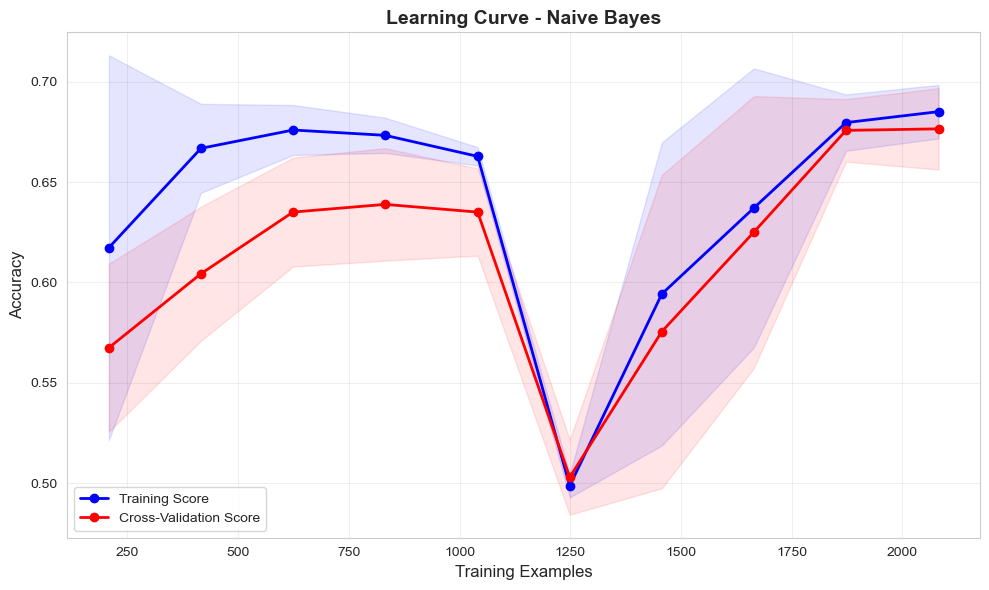


--- SVM ---
  Cross-validated Accuracy: 0.7038 (+/- 0.0241)
  Cross-validated F1 Score:  0.7069 (+/- 0.0285)


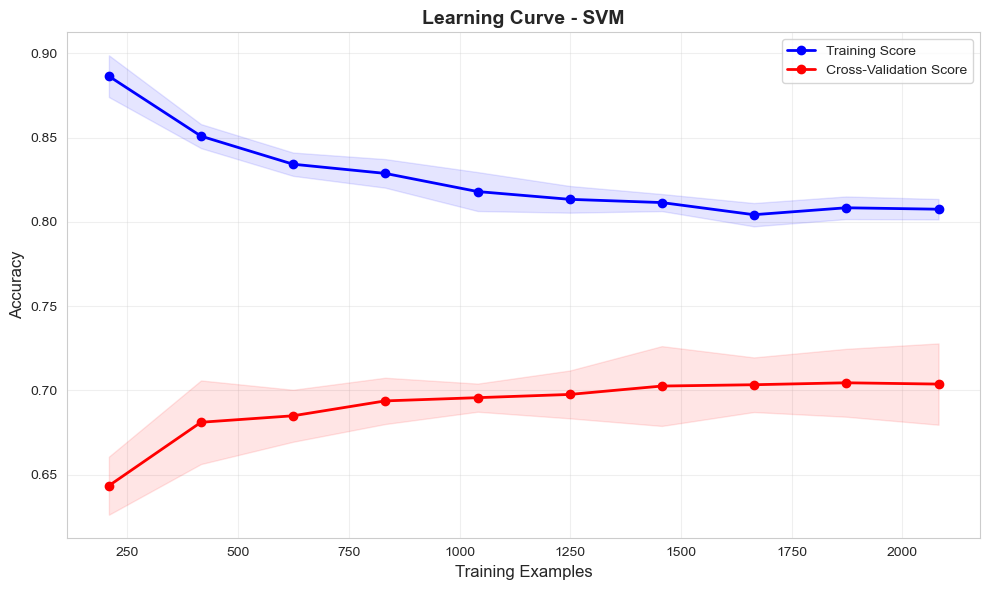


SUMMARY OF CROSS-VALIDATION RESULTS
Classifier      CV Accuracy          CV F1 Score         
-------------------------------------------------------
Naive Bayes     0.6762 +/- 0.0198   0.7042 +/- 0.0133
SVM             0.7038 +/- 0.0241   0.7069 +/- 0.0285


In [12]:
# Initialize classifiers with default values
classifiers = {
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(gamma='auto', random_state=42)
}

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
results = {}

for name, clf in classifiers.items():
    print(f"\n--- {name} ---")
    
    # Cross-validated accuracy
    cv_acc = cross_val_score(clf, X_train, y_train, cv=kf, scoring='accuracy')
    # Cross-validated F1 score
    cv_f1 = cross_val_score(clf, X_train, y_train, cv=kf, scoring='f1')
    
    results[name] = {
        'clf': clf,
        'cv_accuracy_mean': cv_acc.mean(),
        'cv_accuracy_std': cv_acc.std(),
        'cv_f1_mean': cv_f1.mean(),
        'cv_f1_std': cv_f1.std()
    }
    
    print(f"  Cross-validated Accuracy: {cv_acc.mean():.4f} (+/- {cv_acc.std():.4f})")
    print(f"  Cross-validated F1 Score:  {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")
    
    # Draw learning curve
    train_sizes, train_scores, test_scores = learning_curve(
        clf, X_train, y_train, cv=kf,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy',
        n_jobs=-1,
        random_state=42
    )
    
    # Plot learning curve
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', 
             label='Training Score', color='blue', linewidth=2, markersize=6)
    plt.fill_between(train_sizes,
                     train_scores.mean(axis=1) - train_scores.std(axis=1),
                     train_scores.mean(axis=1) + train_scores.std(axis=1),
                     alpha=0.1, color='blue')
    
    plt.plot(train_sizes, test_scores.mean(axis=1), 'o-', 
             label='Cross-Validation Score', color='red', linewidth=2, markersize=6)
    plt.fill_between(train_sizes,
                     test_scores.mean(axis=1) - test_scores.std(axis=1),
                     test_scores.mean(axis=1) + test_scores.std(axis=1),
                     alpha=0.1, color='red')
    
    plt.title(f'Learning Curve - {name}', fontsize=14, fontweight='bold')
    plt.xlabel('Training Examples', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Display summary of all results
print("\n" + "="*60)
print("SUMMARY OF CROSS-VALIDATION RESULTS")
print("="*60)
print(f"{'Classifier':<15} {'CV Accuracy':<20} {'CV F1 Score':<20}")
print("-" * 55)
for name, res in results.items():
    print(f"{name:<15} {res['cv_accuracy_mean']:.4f} +/- {res['cv_accuracy_std']:.4f}   {res['cv_f1_mean']:.4f} +/- {res['cv_f1_std']:.4f}")

# Best model evaluation

Best model (by highest F1 score): SVM
  Cross-validated F1 Score: 0.7069
  Cross-validated Accuracy: 0.7038

--- Test Set Evaluation ---
Test Accuracy Score: 0.7542

Confusion Matrix:
                     Predicted Attrited (0)  Predicted Existing (1)
Actual Attrited (0)                     238                      88
Actual Existing (1)                      72                     253

Classification Report:
              precision    recall  f1-score   support

Attrited (0)       0.77      0.73      0.75       326
Existing (1)       0.74      0.78      0.76       325

    accuracy                           0.75       651
   macro avg       0.75      0.75      0.75       651
weighted avg       0.75      0.75      0.75       651



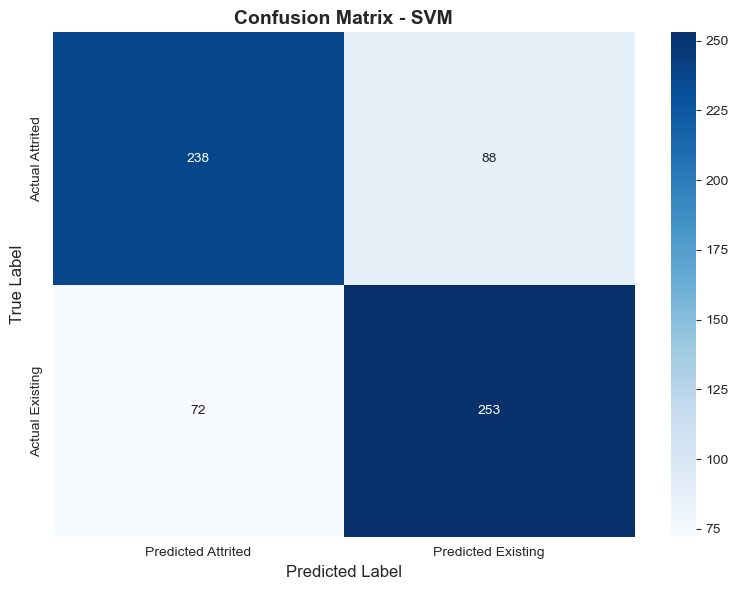

In [15]:
# Find best model by F1 score
best_model_name = max(results, key=lambda x: results[x]['cv_f1_mean'])
best_clf = results[best_model_name]['clf']

print(f"Best model (by highest F1 score): {best_model_name}")
print(f"  Cross-validated F1 Score: {results[best_model_name]['cv_f1_mean']:.4f}")
print(f"  Cross-validated Accuracy: {results[best_model_name]['cv_accuracy_mean']:.4f}")

# Train on full training set
best_clf.fit(X_train, y_train)

# Make predictions on test set
y_pred = best_clf.predict(X_test)

# Evaluation metrics
test_accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- Test Set Evaluation ---")
print(f"Test Accuracy Score: {test_accuracy:.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, 
                   index=['Actual Attrited (0)', 'Actual Existing (1)'],
                   columns=['Predicted Attrited (0)', 'Predicted Existing (1)']))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Attrited (0)', 'Existing (1)']))

# Visualize confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Attrited', 'Predicted Existing'],
            yticklabels=['Actual Attrited', 'Actual Existing'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Training accuracy vs testing accuracy

In [16]:
print("""
If the model's training accuracy (from cross-validation) is significantly 
higher than the test accuracy, this indicates OVERFITTING — the model has 
learned the training data too well but cannot generalise to unseen data.

If the two values are close to each other, the model generalises well and 
is considered a good fit. In an ideal model, the test accuracy should be 
close to (or only slightly below) the training accuracy, showing that the 
model performs consistently on both seen and unseen data.
""")


If the model's training accuracy (from cross-validation) is significantly 
higher than the test accuracy, this indicates OVERFITTING — the model has 
learned the training data too well but cannot generalise to unseen data.

If the two values are close to each other, the model generalises well and 
is considered a good fit. In an ideal model, the test accuracy should be 
close to (or only slightly below) the training accuracy, showing that the 
model performs consistently on both seen and unseen data.

